<a href="https://colab.research.google.com/github/GUEST72/CSC311-Machine-Learning-projects/blob/main/assignment_3%20/%20Gaussian_Discriminant_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

from scipy.stats import skew, kurtosis, jarque_bera, normaltest, zscore, multivariate_normal

#Data Loading & Preprocessing
## **Why merge the classes?**

The original Wine Quality dataset is imbalanced: most samples are rated 5–6, while very few are rated 3, 4, 8, or 9. This makes it hard for models to learn minority classes.

We merged the scores into three groups:

Low (3–4)

Medium (5–6)

High (7–9)

This reduces imbalance and gives a more practical interpretation (poor / average / good wine quality).

## **Handle Outliers (Z-score > 3)**
####**Empirical Rule (68-95-99.7 Rule): For a normal distribution:**

*   About 68% of the data falls within 1 standard deviation of the mean.
*  About 95% of the data falls within 2 standard deviations of the mean.
*  About 99.7% of the data falls within 3 standard deviations of the mean.







In [ ]:

def load_and_preprocess(file_path):
    data = pd.read_csv(file_path, sep=";")
    data["quality_level"] = data["quality"].apply(lambda q: "Low" if q<=4 else "Medium" if q<=6 else "High")
    print("Quality distribution:\n", data["quality_level"].value_counts())
    return data.drop(columns=["quality","quality_level"]), data["quality_level"]

def remove_outliers(X, y, z_thresh=3):
    mask = (np.abs(zscore(X)) < z_thresh).all(axis=1)
    return X[mask], y[mask]

def split_and_scale(X, y):
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

    scaler = StandardScaler().fit(X_train)
    return scaler.transform(X_train), scaler.transform(X_val), scaler.transform(X_test), y_train, y_val, y_test


# **Gaussian Assumption Check**
### Relationship between Skewness, Kurtosis, and the Gaussian Assumption

*   **Skewness:** Measures the asymmetry of the distribution.
    *   A Gaussian distribution is symmetrical and has a skewness of **zero**.
    *   Positive or negative skewness indicates asymmetry and deviation from the Gaussian shape.

*   **Kurtosis:** Measures the "tailedness" and peak shape of the distribution compared to the Gaussian distribution.
    *   A Gaussian distribution has an Excess Kurtosis of **zero**.
    *   Positive excess kurtosis indicates heavier tails and a sharper peak.
    *   Negative excess kurtosis indicates lighter tails and a flatter peak.

**Summary:**

When the skewness and excess kurtosis values are close to zero, it supports the assumption that the data follows a Gaussian distribution. This check is important for models that assume a Gaussian distribution for the data.

In [ ]:

def check_gaussian(X, top_n=6):
    results = []
    for col in X.columns:
        vals = X[col].values
        s, k = skew(vals), kurtosis(vals)
        jb_p, da_p = jarque_bera(vals)[1], normaltest(vals)[1]
        results.append([col, s, k, abs(s)+abs(k), jb_p, da_p])

    df = pd.DataFrame(results, columns=["feature","skew","kurtosis","score","JB_p","DA_p"])
    print(df.round(3))
    selected = df.sort_values("score").head(top_n)["feature"].tolist()
    print("\nSelected features:", selected)

    X[selected].hist(bins=20, figsize=(12,6))
    plt.suptitle("Gaussian Assumption Check", y=1.02)
    plt.show()
    return selected


In [ ]:
class GaussianDiscriminantAnalysis:
    def __init__(self, shared_covariance=True):
        self.shared_covariance = shared_covariance
        self.classes_, self.priors_, self.means_, self.covariances_ = None, {}, {}, {}

    def fit(self, X, y):
        X, y = np.array(X), np.array(y)
        self.classes_ = np.unique(y)
        n_samples, n_features = X.shape

        # Priors & Means
        for k in self.classes_:
            X_k = X[y == k]
            self.priors_[k] = len(X_k) / n_samples
            self.means_[k] = np.mean(X_k, axis=0)


        # Covariance
        if self.shared_covariance:
            # Calculate shared covariance matrix for all data
            cov = np.cov(X.T, bias=False) # bias=False for sample covariance
            for k in self.classes_:
                 # Assign the shared covariance matrix to each class
                self.covariances_[k] = cov
        else:
            for k in self.classes_:
                X_k = X[y == k]
                 # Calculate covariance matrix for each class separately
                self.covariances_[k] = np.cov(X_k.T, bias=False) # bias=False for sample covariance

        return self

    def _log_likelihood(self, X, k):
        # Calculate the log probability density function for each class
        # Add a small value (e.g., 1e-6) to the diagonal of the covariance matrix for numerical stability if needed
        # cov_stable = self.covariances_[k] + np.eye(self.covariances_[k].shape[0]) * 1e-6
        return multivariate_normal.logpdf(X, mean=self.means_[k], cov=self.covariances_[k])

    def predict_proba(self, X):
        X = np.array(X)
        # Calculate the log of the posterior probability for each class
        # log(P(k|X)) = log(P(X|k)) + log(P(k)) + constant
        # where log(P(X|k)) is the log likelihood and log(P(k)) is the log prior
        log_post = np.array([
            self._log_likelihood(X, k) + np.log(self.priors_[k])
            for k in self.classes_
        ]).T
        # Normalize the log probabilities to prevent overflow when exponentiating
        log_post -= log_post.max(axis=1, keepdims=True)
        # Convert log probabilities to actual probabilities
        probs = np.exp(log_post)
        # Normalize probabilities to sum to 1
        return probs / probs.sum(axis=1, keepdims=True)

    def predict(self, X):
        # Predict the class with the highest posterior probability
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]

    def score(self, X, y):
        # Calculate the accuracy of the model
        return accuracy_score(y, self.predict(X))

In [ ]:
# Analyze the effect of covariance type on model performance
def analyze_covariance(X_train, X_val, y_train, y_val):

    # Train LDA with shared covariance
    lda = GaussianDiscriminantAnalysis(True).fit(X_train, y_train)
    # Train QDA with unshared covariance
    qda = GaussianDiscriminantAnalysis(False).fit(X_train, y_train)

    # Print validation accuracy for both models
    print("LDA val acc:", lda.score(X_val, y_val))
    print("QDA val acc:", qda.score(X_val, y_val))
    return lda, qda


In [ ]:

# Analyze the correlation between features
def analyze_correlation(X, features):

    # Create a DataFrame from the features and compute the correlation matrix
    corr = pd.DataFrame(X, columns=features).corr()
    # Visualize the correlation matrix using a heatmap
    sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
    plt.show()


In [ ]:
# Analyze the effect of dimensionality on model performance
def analyze_dimensionality(X_train, X_val, y_train, y_val, max_features):

    scores = {"lda":[], "qda":[]}
    # Iterate through different numbers of features
    for n in range(2, max_features+1):
        # Train LDA and QDA models with the current number of features
        lda = GaussianDiscriminantAnalysis(True).fit(X_train[:,:n], y_train)
        qda = GaussianDiscriminantAnalysis(False).fit(X_train[:,:n], y_train)
        # Append validation scores to the scores dictionary
        scores["lda"].append(lda.score(X_val[:,:n], y_val))
        scores["qda"].append(qda.score(X_val[:,:n], y_val))
        # Print the validation scores for the current number of features
        print(f"Features={n}: LDA={scores['lda'][-1]:.3f}, QDA={scores['qda'][-1]:.3f}")
    # Plot the validation scores for both models
    plt.plot(range(2,max_features+1), scores["lda"], label="LDA")
    plt.plot(range(2,max_features+1), scores["qda"], label="QDA")
    plt.legend(); plt.show()


In [ ]:

# Compare our GDA implementation with scikit-learn's LDA and QDA
def compare_with_sklearn(X_train, X_val, X_test, y_train, y_val, y_test):

    # Define the models to compare
    models = {
        "Our LDA": GaussianDiscriminantAnalysis(True),
        "Our QDA": GaussianDiscriminantAnalysis(False),
        "Sklearn LDA": LinearDiscriminantAnalysis(),
        "Sklearn QDA": QuadraticDiscriminantAnalysis()
    }
    # Iterate through the models and evaluate their performance
    for name, model in models.items():
        model.fit(X_train, y_train)
        # Print the performance metrics for each model
        print(f"{name}: Train={model.score(X_train,y_train):.3f}, Val={model.score(X_val,y_val):.3f}, Test={model.score(X_test,y_test):.3f}")

Quality distribution:
 quality_level
Medium    3655
High      1060
Low        183
Name: count, dtype: int64
                 feature   skew  kurtosis  score  JB_p  DA_p
0          fixed acidity  0.302     0.188  0.490   0.0   0.0
1       volatile acidity  0.748     0.636  1.384   0.0   0.0
2            citric acid  0.431     1.113  1.544   0.0   0.0
3         residual sugar  0.708    -0.572  1.279   0.0   0.0
4              chlorides  1.050     3.427  4.477   0.0   0.0
5    free sulfur dioxide  0.362    -0.281  0.643   0.0   0.0
6   total sulfur dioxide  0.270    -0.290  0.560   0.0   0.0
7                density  0.261    -0.799  1.059   0.0   0.0
8                     pH  0.278    -0.048  0.326   0.0   0.0
9              sulphates  0.647     0.291  0.938   0.0   0.0
10               alcohol  0.443    -0.749  1.192   0.0   0.0

Selected features: ['pH', 'fixed acidity', 'total sulfur dioxide', 'free sulfur dioxide', 'sulphates', 'density']


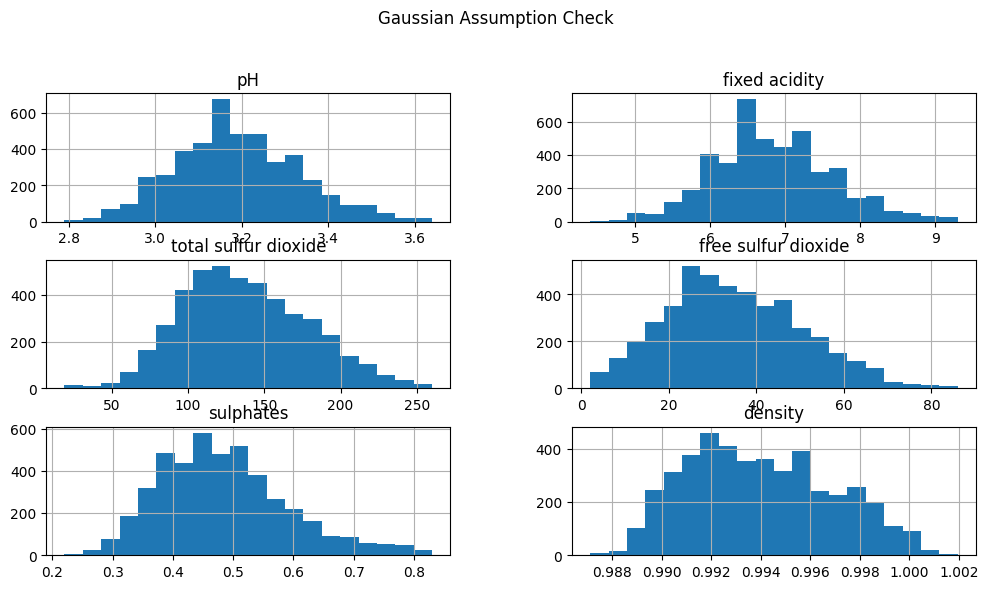

LDA val acc: 0.7437037037037038
QDA val acc: 0.7451851851851852


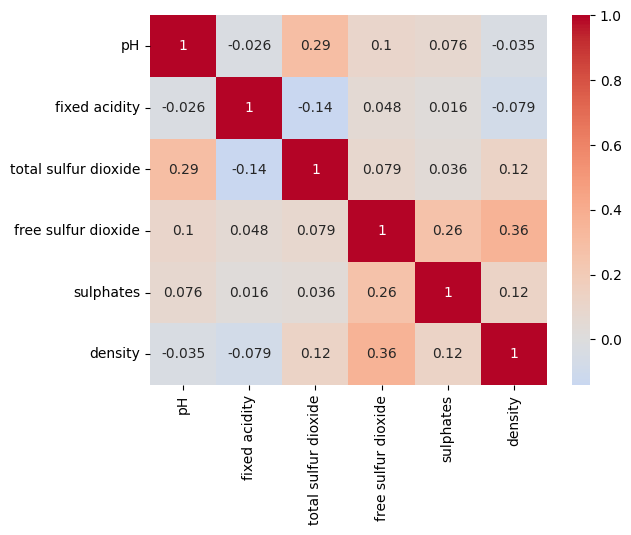

Features=2: LDA=0.744, QDA=0.744
Features=3: LDA=0.744, QDA=0.741
Features=4: LDA=0.744, QDA=0.732
Features=5: LDA=0.744, QDA=0.741
Features=6: LDA=0.744, QDA=0.745


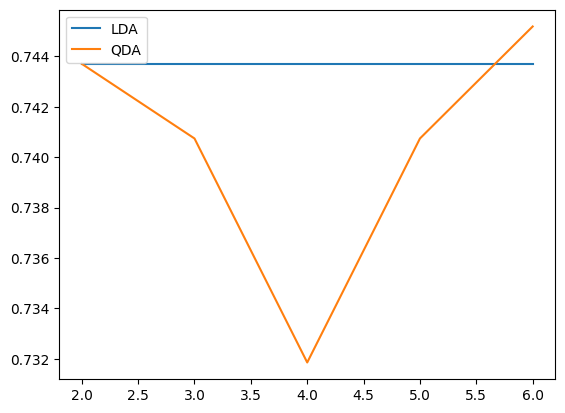

Our LDA: Train=0.743, Val=0.744, Test=0.744
Our QDA: Train=0.746, Val=0.745, Test=0.749
Sklearn LDA: Train=0.744, Val=0.744, Test=0.744
Sklearn QDA: Train=0.746, Val=0.745, Test=0.749


In [ ]:

X, y = load_and_preprocess("/content/drive/MyDrive/Datasets/winequality-white.csv")

X_no_out, y_no_out = remove_outliers(X, y)

selected = check_gaussian(X_no_out)

X_train, X_val, X_test, y_train, y_val, y_test = split_and_scale(X_no_out, y_no_out)

X_train, X_val, X_test = X_train[:,:len(selected)], X_val[:,:len(selected)], X_test[:,:len(selected)]

lda, qda = analyze_covariance(X_train, X_val, y_train, y_val)
analyze_correlation(X_train, selected)
analyze_dimensionality(X_train, X_val, y_train, y_val, len(selected))
compare_with_sklearn(X_train, X_val, X_test, y_train, y_val, y_test)



--- Model Evaluation on Test Set ---

Evaluating Our LDA:
Accuracy: 0.744
Classification Report:
              precision    recall  f1-score   support

        High       0.50      0.01      0.01       153
         Low       0.50      0.05      0.09        20
      Medium       0.75      1.00      0.85       503

    accuracy                           0.74       676
   macro avg       0.58      0.35      0.32       676
weighted avg       0.68      0.74      0.64       676



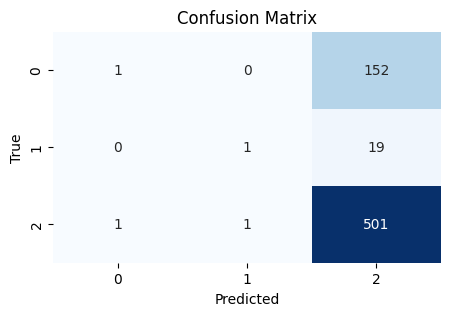


Evaluating Our QDA:
Accuracy: 0.749
Classification Report:
              precision    recall  f1-score   support

        High       0.56      0.22      0.32       153
         Low       0.25      0.10      0.14        20
      Medium       0.77      0.93      0.85       503

    accuracy                           0.75       676
   macro avg       0.53      0.42      0.44       676
weighted avg       0.71      0.75      0.71       676



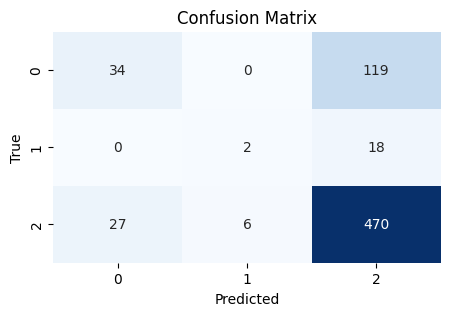

In [ ]:
# Evaluate the performance of the trained models on the test set
print("\n--- Model Evaluation on Test Set ---")

models_to_evaluate = {
    "Our LDA": lda, # Assuming lda is the trained LDA model from yN1gu2_hnoCc
    "Our QDA": qda  # Assuming qda is the trained QDA model from yN1gu2_hnoCc
}

for name, model in models_to_evaluate.items():
    print(f"\nEvaluating {name}:")

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Calculate and print evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)

    print(f"Accuracy: {accuracy:.3f}")
    print("Classification Report:")
    print(report)
    plt.figure(figsize=(5,3))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()



# Note: If you ran the 'compare_with_sklearn' function previously,
# it already printed Train, Val, and Test accuracy for both our models and sklearn's.
# This cell provides a more detailed breakdown with precision and f1-score per class.